# Week 8 Flash Results: Polymarket Cross-Domain Portfolio

This notebook reproduces Week 8 flash-presentation artifacts from cached files generated by `script/polymarket_week8_pipeline.py`.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed = repo_root / "data" / "processed"
figures = repo_root / "figures"

baseline_metrics = json.loads((processed / "baseline_metrics.json").read_text())
constrained_metrics = json.loads((processed / "constrained_best_metrics.json").read_text())
grid = pd.read_csv(processed / "constrained_experiment_grid.csv")

baseline_metrics, constrained_metrics["best_params"]


FileNotFoundError: [Errno 2] No such file or directory: '/Users/adamthomson/Library/Mobile Documents/com~apple~CloudDocs/Documents/UPenn Spring 2026/STAT4830/STAT-4830-energy_arbitrage-project/data/processed/baseline_metrics.json'

In [ ]:
summary = pd.DataFrame([
    {
        "strategy": "equal_weight",
        "sortino": baseline_metrics["sortino_ratio"],
        "max_drawdown": baseline_metrics["max_drawdown"],
        "mean_return": baseline_metrics["mean_return"],
        "volatility": baseline_metrics["volatility"],
    },
    {
        "strategy": "constrained_ogd_sgd",
        "sortino": constrained_metrics["best_params"]["sortino_ratio"],
        "max_drawdown": constrained_metrics["best_params"]["max_drawdown"],
        "mean_return": constrained_metrics["best_params"]["mean_return"],
        "volatility": constrained_metrics["best_params"]["volatility"],
    },
])
summary


,strategy,sortino,max_drawdown,mean_return,volatility
0,equal_weight,0.070584,-0.143530,0.000309,0.014513
1,constrained_ogd_sgd,0.014838,-0.841809,0.000729,0.035909


In [ ]:
grid.sort_values("sortino_ratio", ascending=False).head(8)


,learning_rate,lambda_penalty,rolling_window,sortino_ratio,max_drawdown,mean_return,volatility,domain_exposure_json
11,0.05,10.0,48,0.014838,-0.841809,0.000729,0.035909,"{""us-presidential-election"": 0.000506132346345..."
9,0.05,5.0,48,0.013875,-0.841880,0.000682,0.035570,"{""us-presidential-election"": 0.000451408239314..."
7,0.05,1.0,48,0.013865,-0.841915,0.000682,0.035573,"{""us-presidential-election"": 0.000436908158008..."
3,0.02,5.0,48,0.013846,-0.841552,0.000681,0.035535,"{""us-presidential-election"": 0.000573580677155..."
1,0.02,1.0,48,0.013846,-0.841632,0.000681,0.035543,"{""us-presidential-election"": 0.000547508505405..."
4,0.02,10.0,24,0.013829,-0.841772,0.000680,0.035502,"{""us-presidential-election"": 0.000785914307925..."
2,0.02,5.0,24,0.013824,-0.841810,0.000680,0.035507,"{""us-presidential-election"": 0.000768505153246..."
0,0.02,1.0,24,0.013824,-0.841835,0.000680,0.035509,"{""us-presidential-election"": 0.000759373739128..."


## Flash-Presentation Figures

The script generates these figures directly in `figures/` and they are displayed below.


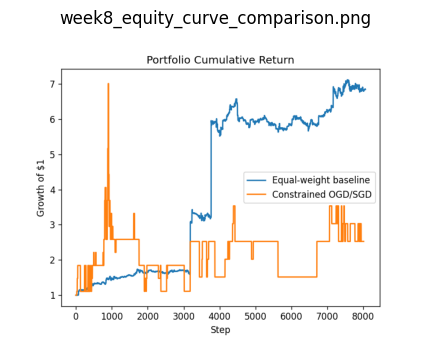

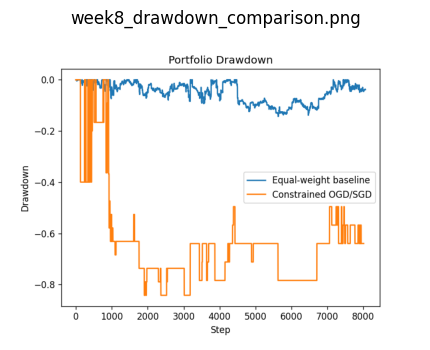

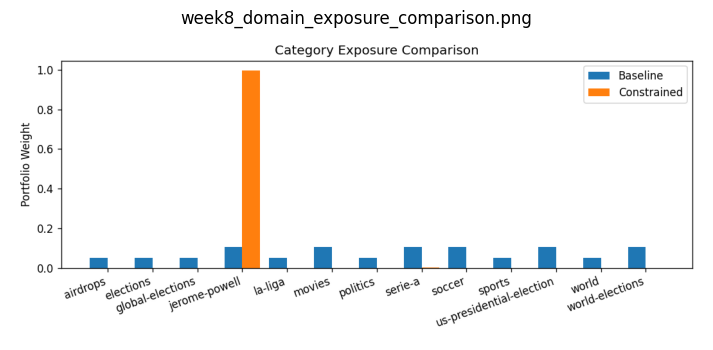

In [ ]:
fig_paths = [
    figures / "week8_equity_curve_comparison.png",
    figures / "week8_drawdown_comparison.png",
    figures / "week8_domain_exposure_comparison.png",
]

for fig_path in fig_paths:
    img = plt.imread(fig_path)
    plt.figure(figsize=(10, 4))
    plt.imshow(img)
    plt.title(fig_path.name)
    plt.axis("off")
    plt.show()


## Interpretation Notes (Week 8)

- Baseline currently has better Sortino and lower drawdown than the first constrained iteration.
- Constrained model is still useful as proof-of-pipeline and objective implementation.
- Next iteration should focus on stronger domain constraints and stabilization so risk metrics improve while reducing over-concentration.
